# Result | Final strategies {#sec-results-final-strategies}

Here, we visualize the final strategies across different levels of environmental uncertainty. We start by importing the required packages, defining some configuations and obtaining the required simulation data.

In [1]:
#| output: asis
print("\\begin{OutputCode}") #| hide_line
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator
plt.rcParams['text.usetex'] = True

from _code.SimulationScripts import collective_intelligence
from _code.ObtainNoiseVariationResults import obtain_all_noise_variation_comparisons, noise_levels
(NoiVar_MBA_pAhigh, NoiVar_MFA_pAhigh,
 NoiVar_MBA_pAmid, NoiVar_MFA_pAmid,
 NoiVar_MBA_pAlow, NoiVar_MFA_pAlow) = obtain_all_noise_variation_comparisons()
print("\\end{OutputCode}") #| hide_line

\begin{OutputCode}
Loading noise variation: ./_data/NOISEVARIATION_TwoAgentUncertainDecisionProblem_probabilityA0.5_likelydistance0.5_LearningAgents_learning_rates0.25_initalX12842151645801287464_maxT5000_Noises7752999609125433264.npz
Loading noise variation: ./_data/NOISEVARIATION_SingleAgentUncertainDecisionProblem_probabilityA0.5_likelydistance0.5_LearningAgents_learning_rates0.25_initalX7794212447693859915_maxT5000_Noises7752999609125433264.npz
Loading noise variation: ./_data/NOISEVARIATION_TwoAgentUncertainDecisionProblem_probabilityA0.5_likelydistance0.5_ModelFreeAgents_learning_rates0.25_initalX12631382026377322370_maxT250000_Noises7752999609125433264.npz
Loading noise variation: ./_data/NOISEVARIATION_SingleAgentUncertainDecisionProblem_probabilityA0.5_likelydistance0.5_ModelFreeAgents_learning_rates0.25_initalX9145693657658906017_maxT250000_Noises7752999609125433264.npz
Loading noise variation: ./_data/NOISEVARIATION_TwoAgentUncertainDecisionProblem_probabilityA0.58_likelydis

### Final strategies

First, we create a function to visualize the final strategies from a noise-variation dataset `NoiVar`.

In [4]:
def plot_final_behaviors(NoiVar, noise_levels, ax_sa=None, ax_ta=None):
    if ax_sa is None and ax_ta is None:
        fsf = 0.7
        fig = plt.figure(figsize=(fsf*6, fsf*5))
        gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3], hspace=0.3)
        ax_sa = fig.add_subplot(gs[0])
        ax_ta = fig.add_subplot(gs[1])
        
        ax_ta.set_xlabel('Observational uncertainty $\\sigma$')


    n = np.newaxis
    # Single agent policies
    sa_finalpolicies_Xon = NoiVar.sa_Xnkioa[..., 0].mean(axis=(1,2)).T
    sa_envsignalaction_o = np.array([1, 1, 0, 0])
    sa_finalpolicies_Xon = np.abs(sa_finalpolicies_Xon - sa_envsignalaction_o[:,n])
    sa_finalpolicies_Xon = sa_finalpolicies_Xon.astype(np.float64)

    sa_maOset = np.array(['\\texttt{A\\underline{.}}', '\\texttt{a\\underline{.}}', 
                          '\\texttt{b\\underline{.}}', '\\texttt{B\\underline{.}}'])
    ax_sa.pcolormesh(noise_levels, np.arange(4), sa_finalpolicies_Xon, cmap='Blues', vmin=0.0, vmax=1.0)
    ax_sa.invert_yaxis()
    ax_sa.set_yticks(np.arange(0, 4))
    ax_sa.set_yticklabels(sa_maOset);

    # Two agent policies
    ta_finalpolicies_Xon = NoiVar.ta_Xnkioa[..., 0].mean(axis=(1,2)).T[:12]
    ta_envsignalaction_o = np.array([1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0])
    ta_finalpolicies_Xon = np.abs(ta_finalpolicies_Xon - ta_envsignalaction_o[:,n])
    ta_finalpolicies_Xon = ta_finalpolicies_Xon.astype(np.float64)

    ta_maOset = np.array(['\\texttt{A\\underline{.}}', '\\texttt{a\\underline{.}}', 
                          '\\texttt{b\\underline{.}}', '\\texttt{B\\underline{.}}', 
                          '\\texttt{A\\underline{A}}', '\\texttt{a\\underline{A}}', 
                          '\\texttt{b\\underline{A}}', '\\texttt{B\\underline{A}}', 
                          '\\texttt{A\\underline{B}}', '\\texttt{a\\underline{B}}', 
                          '\\texttt{b\\underline{B}}', '\\texttt{B\\underline{B}}', 
                        '..'])
    ax_ta.pcolormesh(noise_levels, np.arange(12), ta_finalpolicies_Xon, cmap='Oranges', vmin=0.0, vmax=1.0)
    ax_ta.invert_yaxis()
    ax_ta.set_yticks(np.arange(0, 12))
    ax_ta.set_yticklabels(ta_maOset[:12]);
    # ax_ta.annotate("Action choice not following nature's signal", xy=(-0.062, 0.74),
                    # rotation=90, ha='center',va='center', xycoords='axes fraction')


    xlim=[-0.05, max(noise_levels)+0.05]
    ax_ta.plot(xlim, [3.5,3.5], '-', color='gray', lw=0.5)
    ax_ta.plot(xlim, [7.5,7.5],  '-', color='gray', lw=0.5)
    ax_ta.plot(xlim, [11.5,11.5], '-', color='gray', lw=0.5)
    ax_ta.set_xlim(xlim); ax_sa.set_xlim(xlim);

    ax_sa.xaxis.set_minor_locator(MultipleLocator(0.2))
    ax_ta.xaxis.set_minor_locator(MultipleLocator(0.2))


This function yields, for example,

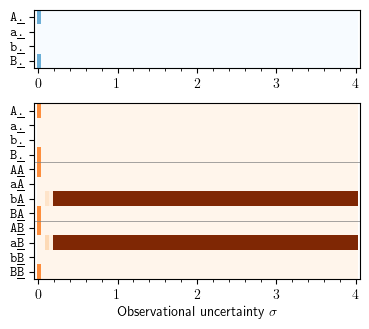

In [5]:
#| fig-cap: Example plot for final strategies versus observational uncertainty.
plot_final_behaviors(NoiVar_MBA_pAhigh, noise_levels)

### Reward outperformance

Second, we create a function to visualize the reward outperformance from a noise-variation dataset `NoiVar`.

In [6]:
def plot_reward_outperformance(NoiVar, noise_levels, ax=None):
    if ax is None:
        fsf = 0.7
        fig = plt.figure(figsize=(fsf*6, fsf*4))
        ax = fig.add_subplot(1,1,1)
        ax.set_xlabel('Observational uncertainty $\\sigma$')
        ax.set_ylabel('Final reward outperformance');
        
    CInk = collective_intelligence(NoiVar.ta_Rnki.mean(-1),
                                   NoiVar.sa_Rnki.mean(-1))
    ax.plot(noise_levels, CInk.mean(-1), marker=".", ms=2, lw=0.5, color="k")
    xlim=[-0.05, max(noise_levels)+0.05]
    ax.set_xlim(xlim); ax.set_ylim([-0.005, 0.145])
    ax.xaxis.set_minor_locator(MultipleLocator(0.2))


This function yields, for example,

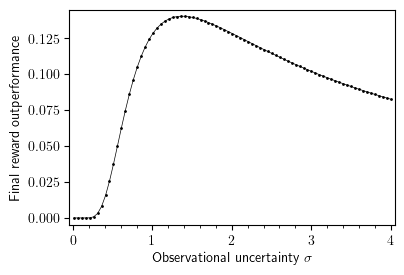

In [7]:
#| fig-cap: Example plot for reward outperformance versus observational uncertainty.
plot_reward_outperformance(NoiVar_MBA_pAhigh, noise_levels)

We define two helper functions to plot vertical lines to better visualize the critical levels of observational uncertainty where strategy transitions occur.

In [8]:
def plot_vertical_line_at_noise_level(ax, noise_level, ls='-'):
    ax.plot([noise_level, noise_level], ax.get_ylim(), ls, color='gray', lw=0.5)

In [9]:
def plot_vertical_lines_at_all_axes(axes, noise_level, ls='-'):
    for ax in axes: plot_vertical_line_at_noise_level(ax, noise_level, ls)

Putting everything together, we create the Figure 3 of the main text showing the learned strategies.

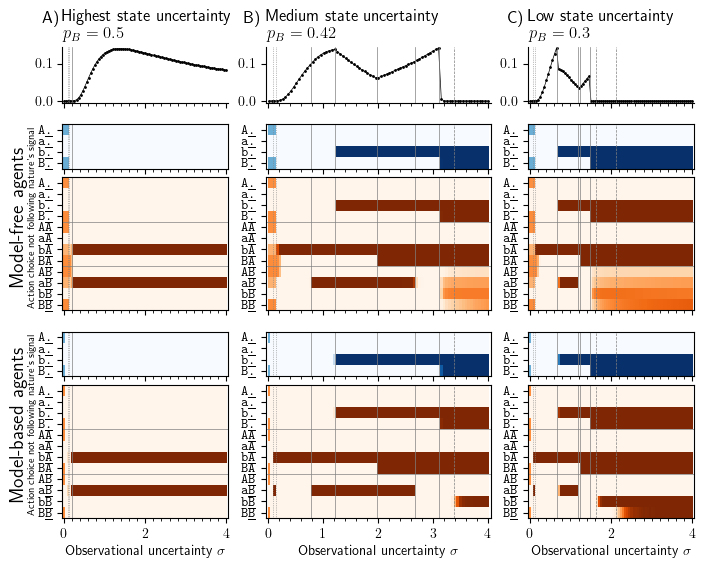

In [10]:
#| fig-cap: Figure 3 of the main text showing the learned strategies.
fsf = 0.34
fig = plt.figure(figsize=(fsf*24, fsf*18))

gs = GridSpec(3, 3, hspace=0.15, wspace=0.2,
              height_ratios=[1.2, 4, 4], width_ratios=[1,1.35,1])

titleparams = dict(loc="left")
ABCparams = dict(xy=(-0.02, 1.65), ha='right', va='top',
                 xycoords='axes fraction', fontsize=12, fontweight='bold')
agentmodelparams = dict(xy=(-0.26, 0.7), rotation=90, fontsize=14, ha='center',
                       va='center', xycoords='axes fraction', fontweight='bold')   
actchoiceparams = dict(xy=(-0.18, 0.7), rotation=90, fontsize=7, ha='center',
                       va='center', xycoords='axes fraction')


## 1 | Highest state uncertainty (p(A)=0.5)
ax_rop_high = fig.add_subplot(gs[0, 0]); 
ax_rop_high.set_title("Highest state uncertainty\n$p_B=0.5$", **titleparams)
ax_rop_high.annotate("A)", **ABCparams)
plot_reward_outperformance(NoiVar_MBA_pAhigh, noise_levels, ax_rop_high)
ax_rop_high.set_xticklabels([]);
ax_rop_high.spines[['top', 'right']].set_visible(False)


gs_mfa_high = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[1,0],
                                               height_ratios=[1, 3], hspace=0.1)
ax_mfa_high_sa = fig.add_subplot(gs_mfa_high[0])
ax_mfa_high_ta = fig.add_subplot(gs_mfa_high[1])
plot_final_behaviors(NoiVar_MFA_pAhigh, noise_levels, ax_mfa_high_sa, ax_mfa_high_ta)
ax_mfa_high_ta.annotate("Action choice not following nature's signal",
                        **actchoiceparams)
ax_mfa_high_ta.annotate("Model-free agents", **agentmodelparams)
ax_mfa_high_sa.set_xticklabels([]);
ax_mfa_high_ta.set_xticklabels([]);

gs_mba_high = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[2,0],
                                               height_ratios=[1, 3], hspace=0.1)
ax_mba_high_sa = fig.add_subplot(gs_mba_high[0])
ax_mba_high_ta = fig.add_subplot(gs_mba_high[1])        
plot_final_behaviors(NoiVar_MBA_pAhigh, noise_levels, ax_mba_high_sa, ax_mba_high_ta)
ax_mba_high_ta.annotate("Action choice not following nature's signal",
                        **actchoiceparams)
ax_mba_high_ta.annotate("Model-based agents", **agentmodelparams)
ax_mba_high_sa.set_xticklabels([]);
ax_mba_high_ta.set_xlabel("Observational uncertainty $\\sigma$");

axes = [ax_rop_high, ax_mfa_high_sa, ax_mfa_high_ta, ax_mba_high_sa, ax_mba_high_ta]
plot_vertical_lines_at_all_axes(axes, 0.09, ls=':')
plot_vertical_lines_at_all_axes(axes, 0.13, ls=':')
plot_vertical_lines_at_all_axes(axes, 0.19)



## 2 | Medium state uncertainty (p(A)=0.6)
ax_rop_mid  = fig.add_subplot(gs[0, 1])
ax_rop_mid.set_title("Medium state uncertainty\n$p_B=0.42$", **titleparams)
ax_rop_mid.annotate("B)", **ABCparams)
plot_reward_outperformance(NoiVar_MBA_pAmid, noise_levels, ax_rop_mid)
ax_rop_mid.set_xticklabels([]);
ax_rop_mid.spines[['top', 'right']].set_visible(False)

gs_mfa_mid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[1,1],
                                              height_ratios=[1, 3], hspace=0.1)
ax_mfa_mid_sa = fig.add_subplot(gs_mfa_mid[0])
ax_mfa_mid_ta = fig.add_subplot(gs_mfa_mid[1])
plot_final_behaviors(NoiVar_MFA_pAmid, noise_levels, ax_mfa_mid_sa, ax_mfa_mid_ta)
ax_mfa_mid_sa.set_xticklabels([]);
ax_mfa_mid_ta.set_xticklabels([]);

gs_mba_mid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[2,1],
                                              height_ratios=[1, 3], hspace=0.1)
ax_mba_mid_sa = fig.add_subplot(gs_mba_mid[0])
ax_mba_mid_ta = fig.add_subplot(gs_mba_mid[1])        
plot_final_behaviors(NoiVar_MBA_pAmid, noise_levels, ax_mba_mid_sa, ax_mba_mid_ta)
ax_mba_mid_sa.set_xticklabels([]);
ax_mba_mid_ta.set_xlabel("Observational uncertainty $\\sigma$");

axes = [ax_rop_mid, ax_mfa_mid_sa, ax_mfa_mid_ta, ax_mba_mid_sa, ax_mba_mid_ta]
plot_vertical_lines_at_all_axes(axes, 0.09, ls=':')
plot_vertical_lines_at_all_axes(axes, 0.13, ls=':')
plot_vertical_lines_at_all_axes(axes, 0.78)
plot_vertical_lines_at_all_axes(axes, 1.22)
plot_vertical_lines_at_all_axes(axes, 1.98)
plot_vertical_lines_at_all_axes(axes, 2.68)
plot_vertical_lines_at_all_axes(axes, 3.11)
plot_vertical_lines_at_all_axes(axes, 3.38, ls="--")


## 3 | Lowest state uncertainty (p(A)=0.7)
ax_rop_low  = fig.add_subplot(gs[0, 2])
ax_rop_low.set_title("Low state uncertainty\n$p_B=0.3$", **titleparams)
ax_rop_low.annotate("C)", **ABCparams)
plot_reward_outperformance(NoiVar_MBA_pAlow, noise_levels, ax_rop_low)  
ax_rop_low.set_xticklabels([]);
ax_rop_low.spines[['top', 'right']].set_visible(False)

gs_mfa_low = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[1,2],
                                              height_ratios=[1, 3], hspace=0.1)
ax_mfa_low_sa = fig.add_subplot(gs_mfa_low[0])
ax_mfa_low_ta = fig.add_subplot(gs_mfa_low[1])
plot_final_behaviors(NoiVar_MFA_pAlow, noise_levels, ax_mfa_low_sa, ax_mfa_low_ta)
ax_mfa_low_sa.set_xticklabels([]);
ax_mfa_low_ta.set_xticklabels([]);

gs_mba_low = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[2,2],
                                              height_ratios=[1, 3], hspace=0.1)
ax_mba_low_sa = fig.add_subplot(gs_mba_low[0])
ax_mba_low_ta = fig.add_subplot(gs_mba_low[1])        
plot_final_behaviors(NoiVar_MBA_pAlow, noise_levels, ax_mba_low_sa, ax_mba_low_ta)
ax_mba_low_sa.set_xticklabels([]);
ax_mba_low_ta.set_xlabel("Observational uncertainty $\\sigma$");

axes = [ax_rop_low, ax_mfa_low_sa, ax_mfa_low_ta, ax_mba_low_sa, ax_mba_low_ta]
plot_vertical_lines_at_all_axes(axes, 0.09, ls=':')
plot_vertical_lines_at_all_axes(axes, 0.13, ls=':')
plot_vertical_lines_at_all_axes(axes, 0.68)
plot_vertical_lines_at_all_axes(axes, 1.18)
plot_vertical_lines_at_all_axes(axes, 1.23)
plot_vertical_lines_at_all_axes(axes, 1.48)
plot_vertical_lines_at_all_axes(axes, 1.63, ls="--")                                
plot_vertical_lines_at_all_axes(axes, 2.13, ls="--")                                
                                
plt.savefig("./_figs/FinalBehaviors.png", bbox_inches='tight', dpi=300)